# FRE-GY 7871A — Assignment 2
## Fed communication tone under Chair Warsh, and the September 16, 2026 meeting

This notebook runs the analysis end to end and produces every exhibit in the report.

The pipeline is in `src/`; this notebook orchestrates it and displays the results:

| Step | Module | Output |
|---|---|---|
| Collect documents and market data | `src.collect` | `data/docs/`, `data/interim/manifest.csv`, `data/market/market.csv` |
| Method 1 — hand-built word list | `src.score_wordlist` | `data/interim/scores_wordlist.csv` |
| Method 2 — FinBERT + numeric direction | `src.score_finbert` | `data/interim/scores_finbert.csv` |
| Table 1, Figure 1 | `src.exhibits` | `outputs/table1_*`, `outputs/figure1_*` |
| Tables 2 and 3 | `src.validate` | `outputs/table2_*`, `outputs/table3_*` |

Run `python -m src.collect`, `python -m src.score_wordlist` and `python -m src.score_finbert` once
before executing this notebook; they cache to `data/`, which is not committed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

from src import exhibits, validate
from src.config import SAMPLE_START, SAMPLE_END, WARSH_START, NEXT_MEETING

print(f"Sample:       {SAMPLE_START} to {SAMPLE_END}")
print(f"Warsh era:    from {WARSH_START}")
print(f"Forecasting:  FOMC meeting of {NEXT_MEETING}")

Sample:       2018-02-01 to 2026-09-15
Warsh era:    from 2026-05-22
Forecasting:  FOMC meeting of 2026-09-16


---
## Table 1. Documents collected, by type and by Chair

In [2]:
manifest = pd.read_csv("data/interim/manifest.csv", parse_dates=["stamp"])
t1 = exhibits.table1(manifest)
display(t1)
print(exhibits.TABLE1_NOTES)

,Document type,Powell (2018-02-01 to 2026-05-21),Warsh (2026-05-22 to 2026-09-15),Total,"Mean words, Powell","Mean words, Warsh"
0,Press release (FOMC statement),68,2,70,379,149
1,Minutes,67,2,69,8278,5493
2,Chair speech / testimony,117,4,121,5566,4767
3,All documents,252,8,260,<NA>,<NA>


Notes. Sample window 2018-02-01 to 2026-09-15; documents are assigned to a
Chair by release date, with the Warsh era beginning 2026-05-22, the date he was
sworn in. Statements and minutes are complete: every FOMC statement and every FOMC
minutes release in the window is included. Minutes of the Board's discount rate
meetings are a separate document and are excluded.

The speech row is deliberately scoped rather than exhaustive. It covers monetary-
policy communication by the sitting Chair only -- semiannual Monetary Policy Report
testimony to Congress, FOMC post-meeting press conference transcripts, and major
policy speeches (Jackson Hole, and speeches whose title or venue concerns the
outlook, inflation, the labour market or the policy framework). Speeches by other
Governors, supervision and regulation testimony, and ceremonial remarks are
excluded. Collecting every speech either Chair gave was not feasible in the time
available; because statements, minutes and press conference transc

The Warsh era holds **8 documents**. That is the binding constraint on everything
downstream, and it is stated wherever N matters rather than buried.

Note also the length difference: Warsh's statements average 149 words against Powell's 379,
and his minutes 5,493 against 8,278. Brevity is itself a communication choice, and it
interacts with the per-word tone measure — see the robustness check below.

In [3]:
warsh_docs = manifest[manifest.chair == "Warsh"].sort_values("stamp")
display(warsh_docs[["stamp", "doc_type", "n_words", "title"]].reset_index(drop=True))

,stamp,doc_type,n_words,title
0,2026-06-17 14:00:00,statement,131,Federal Reserve issues FOMC statement
1,2026-06-17 14:30:00,speech,7138,"FOMC press conference transcript, June 17, 2026"
2,2026-07-08 14:00:00,minutes,5282,"Minutes of the Federal Open Market Committee, ..."
3,2026-07-14 08:30:00,speech,1336,Semiannual Monetary Policy Report to the Congress
4,2026-07-29 14:00:00,statement,167,Federal Reserve issues FOMC statement
5,2026-07-29 14:30:00,speech,7009,"FOMC press conference transcript, July 29, 2026"
6,2026-08-19 14:00:00,minutes,5704,"Minutes of the Federal Open Market Committee, ..."
7,2026-08-28 10:00:00,speech,3584,In Our Time


---
## Method 1 (primary). Hand-built, tf.idf-weighted hawkish/dovish word list

Following Loughran & McDonald (2011): a word list built for the domain, weighted by tf.idf.
Their categories (Negative, Uncertainty, Litigious) do not map onto the hawk–dove axis —
"inflation has eased" and "inflation remains elevated" are both roughly neutral in LM terms
but opposite in policy terms — so the list is written from scratch against FOMC language.

Phrases match as **ordered token chains with a gap budget**, so a phrase may be interrupted
but not stretched across a clause (the Parsing the Fed word-list method).

In [4]:
from src.lexicon import HAWKISH, DOVISH, MAX_GAP
print(f"{len(HAWKISH)} hawkish phrases, {len(DOVISH)} dovish, max gap {MAX_GAP} tokens\n")
print("Hawkish, first 8:", HAWKISH[:8])
print("Dovish,  first 8:", DOVISH[:8])

45 hawkish phrases, 34 dovish, max gap 5 tokens

Hawkish, first 8: ['inflation elevated', 'inflation remain(s|ed)? (too )?high', 'inflation unacceptably high', 'inflation (has )?(risen|increased|picked up)', 'inflation above target', 'inflation above (the )?(committee|2|two) percent', 'upside risks? inflation', 'inflation(ary)? pressures?']
Dovish,  first 8: ['inflation (has )?eas(ed|ing)', 'inflation (has )?(declined|moderated|slowed|fallen|cooled)', 'inflation (has )?(moved|coming) (down|toward)', 'inflation subdued', 'inflation (is )?(muted|low|below)', 'progress (on|toward) (2|inflation) (percent )?(objective|goal|target)', 'greater confidence inflation', 'inflation expectations? (well )?anchored']


In [5]:
scores = validate.load_scores()
display(scores.pivot_table(index="doc_type", columns="chair",
                           values="tone_wordlist", aggfunc="mean")
        .reindex(exhibits.TYPE_ORDER).round(2))

chair,Powell,Warsh
doc_type,,
statement,0.96,37.85
minutes,0.25,5.77
speech,-0.69,3.00


### Validating the lexicon against policy history

The list was checked against what the Fed actually did, not against the regressions it feeds.

In [6]:
annual = scores.assign(year=scores.stamp.dt.year).pivot_table(
    index="year", columns="doc_type", values="tone_wordlist", aggfunc="mean")
display(annual.reindex(columns=exhibits.TYPE_ORDER).round(2))

st = scores[scores.doc_type == "statement"]
print("Most dovish statements in the sample:")
display(st.nsmallest(4, "tone_wordlist")[["stamp", "chair", "n_tokens", "tone_wordlist"]])

doc_type,statement,minutes,speech
year,,,
2018,3.81,1.38,-1.11
2019,-2.23,-3.33,-3.06
2020,-7.88,-2.84,-2.39
2021,-7.83,-2.29,-1.39
2022,23.41,7.41,6.45
2023,25.56,9.12,4.73
2024,-18.50,-4.55,-4.24
2025,-5.40,-2.28,-3.09
2026,14.63,2.19,1.74


Most dovish statements in the sample:


,stamp,chair,n_tokens,tone_wordlist
68,2020-03-03 10:00:00,Powell,128,-30.461920
201,2024-09-18 14:00:00,Powell,360,-27.211893
233,2025-09-17 14:00:00,Powell,340,-26.552248
197,2024-07-31 14:00:00,Powell,362,-24.272814


2022–23 sits at the hawkish extreme and 2020–21 and 2024 at the dovish extreme, which is
the policy cycle. The single most dovish statement in 260 documents is **2020-03-03**, the
emergency intermeeting 50bp cut; the second is **2024-09-18**, the 50bp cut that opened the
easing cycle. The list was not tuned to produce this.

### Robustness: the per-word denominator

The assignment specifies dividing by total words. Warsh's statements are short, so a given
number of hawkish phrases scores higher per word. `tone_balance` is a length-free polarity
ratio in [-1, 1] that ignores document length entirely.

In [7]:
cols = ["stamp", "doc_type", "n_tokens", "hawk_hits", "dove_hits",
        "tone_wordlist", "tone_balance"]
display(scores[scores.chair == "Warsh"][cols].reset_index(drop=True).round(3))

print("Warsh percentile within the Powell-era distribution, by type (tone_balance):")
for dt in exhibits.TYPE_ORDER:
    pw = scores[(scores.chair == "Powell") & (scores.doc_type == dt)].tone_balance
    for v in scores[(scores.chair == "Warsh") & (scores.doc_type == dt)].tone_balance:
        print(f"  {dt:<10} {v:+.3f} -> {(pw < v).mean() * 100:5.1f}th pct of {len(pw)}")

,stamp,doc_type,n_tokens,hawk_hits,dove_hits,tone_wordlist,tone_balance
0,2026-06-17 14:00:00,statement,132,2,0,36.603,1.000
1,2026-06-17 14:30:00,speech,7480,6,1,1.809,0.786
2,2026-07-08 14:00:00,minutes,5330,25,8,5.491,0.594
3,2026-07-14 08:30:00,speech,1346,3,0,4.368,1.000
4,2026-07-29 14:00:00,statement,169,3,0,39.101,1.000
5,2026-07-29 14:30:00,speech,7452,8,1,2.055,0.913
6,2026-08-19 14:00:00,minutes,5755,23,5,6.052,0.689
7,2026-08-28 10:00:00,speech,3566,6,1,3.785,0.820


Warsh percentile within the Powell-era distribution, by type (tone_balance):
  statement  +1.000 ->  75.0th pct of 68
  statement  +1.000 ->  75.0th pct of 68
  minutes    +0.594 ->  85.1th pct of 67
  minutes    +0.689 ->  91.0th pct of 67
  speech     +0.786 ->  98.3th pct of 117
  speech     +1.000 -> 100.0th pct of 117
  speech     +0.913 ->  98.3th pct of 117
  speech     +0.820 ->  98.3th pct of 117


Both measures agree on direction: **every one of the eight Warsh documents is hawkish.**
The four speeches sit at the 97th–100th percentile of 117 Powell-era policy speeches.

They disagree on *magnitude* for statements, and the report says so: Warsh's July statement
ties Powell's May 2023 peak on the per-word measure, but with 3 hawkish phrases against
Powell's 9. Part of the gap is brevity, not stance.

---
## Figure 1. Tone over time by document type

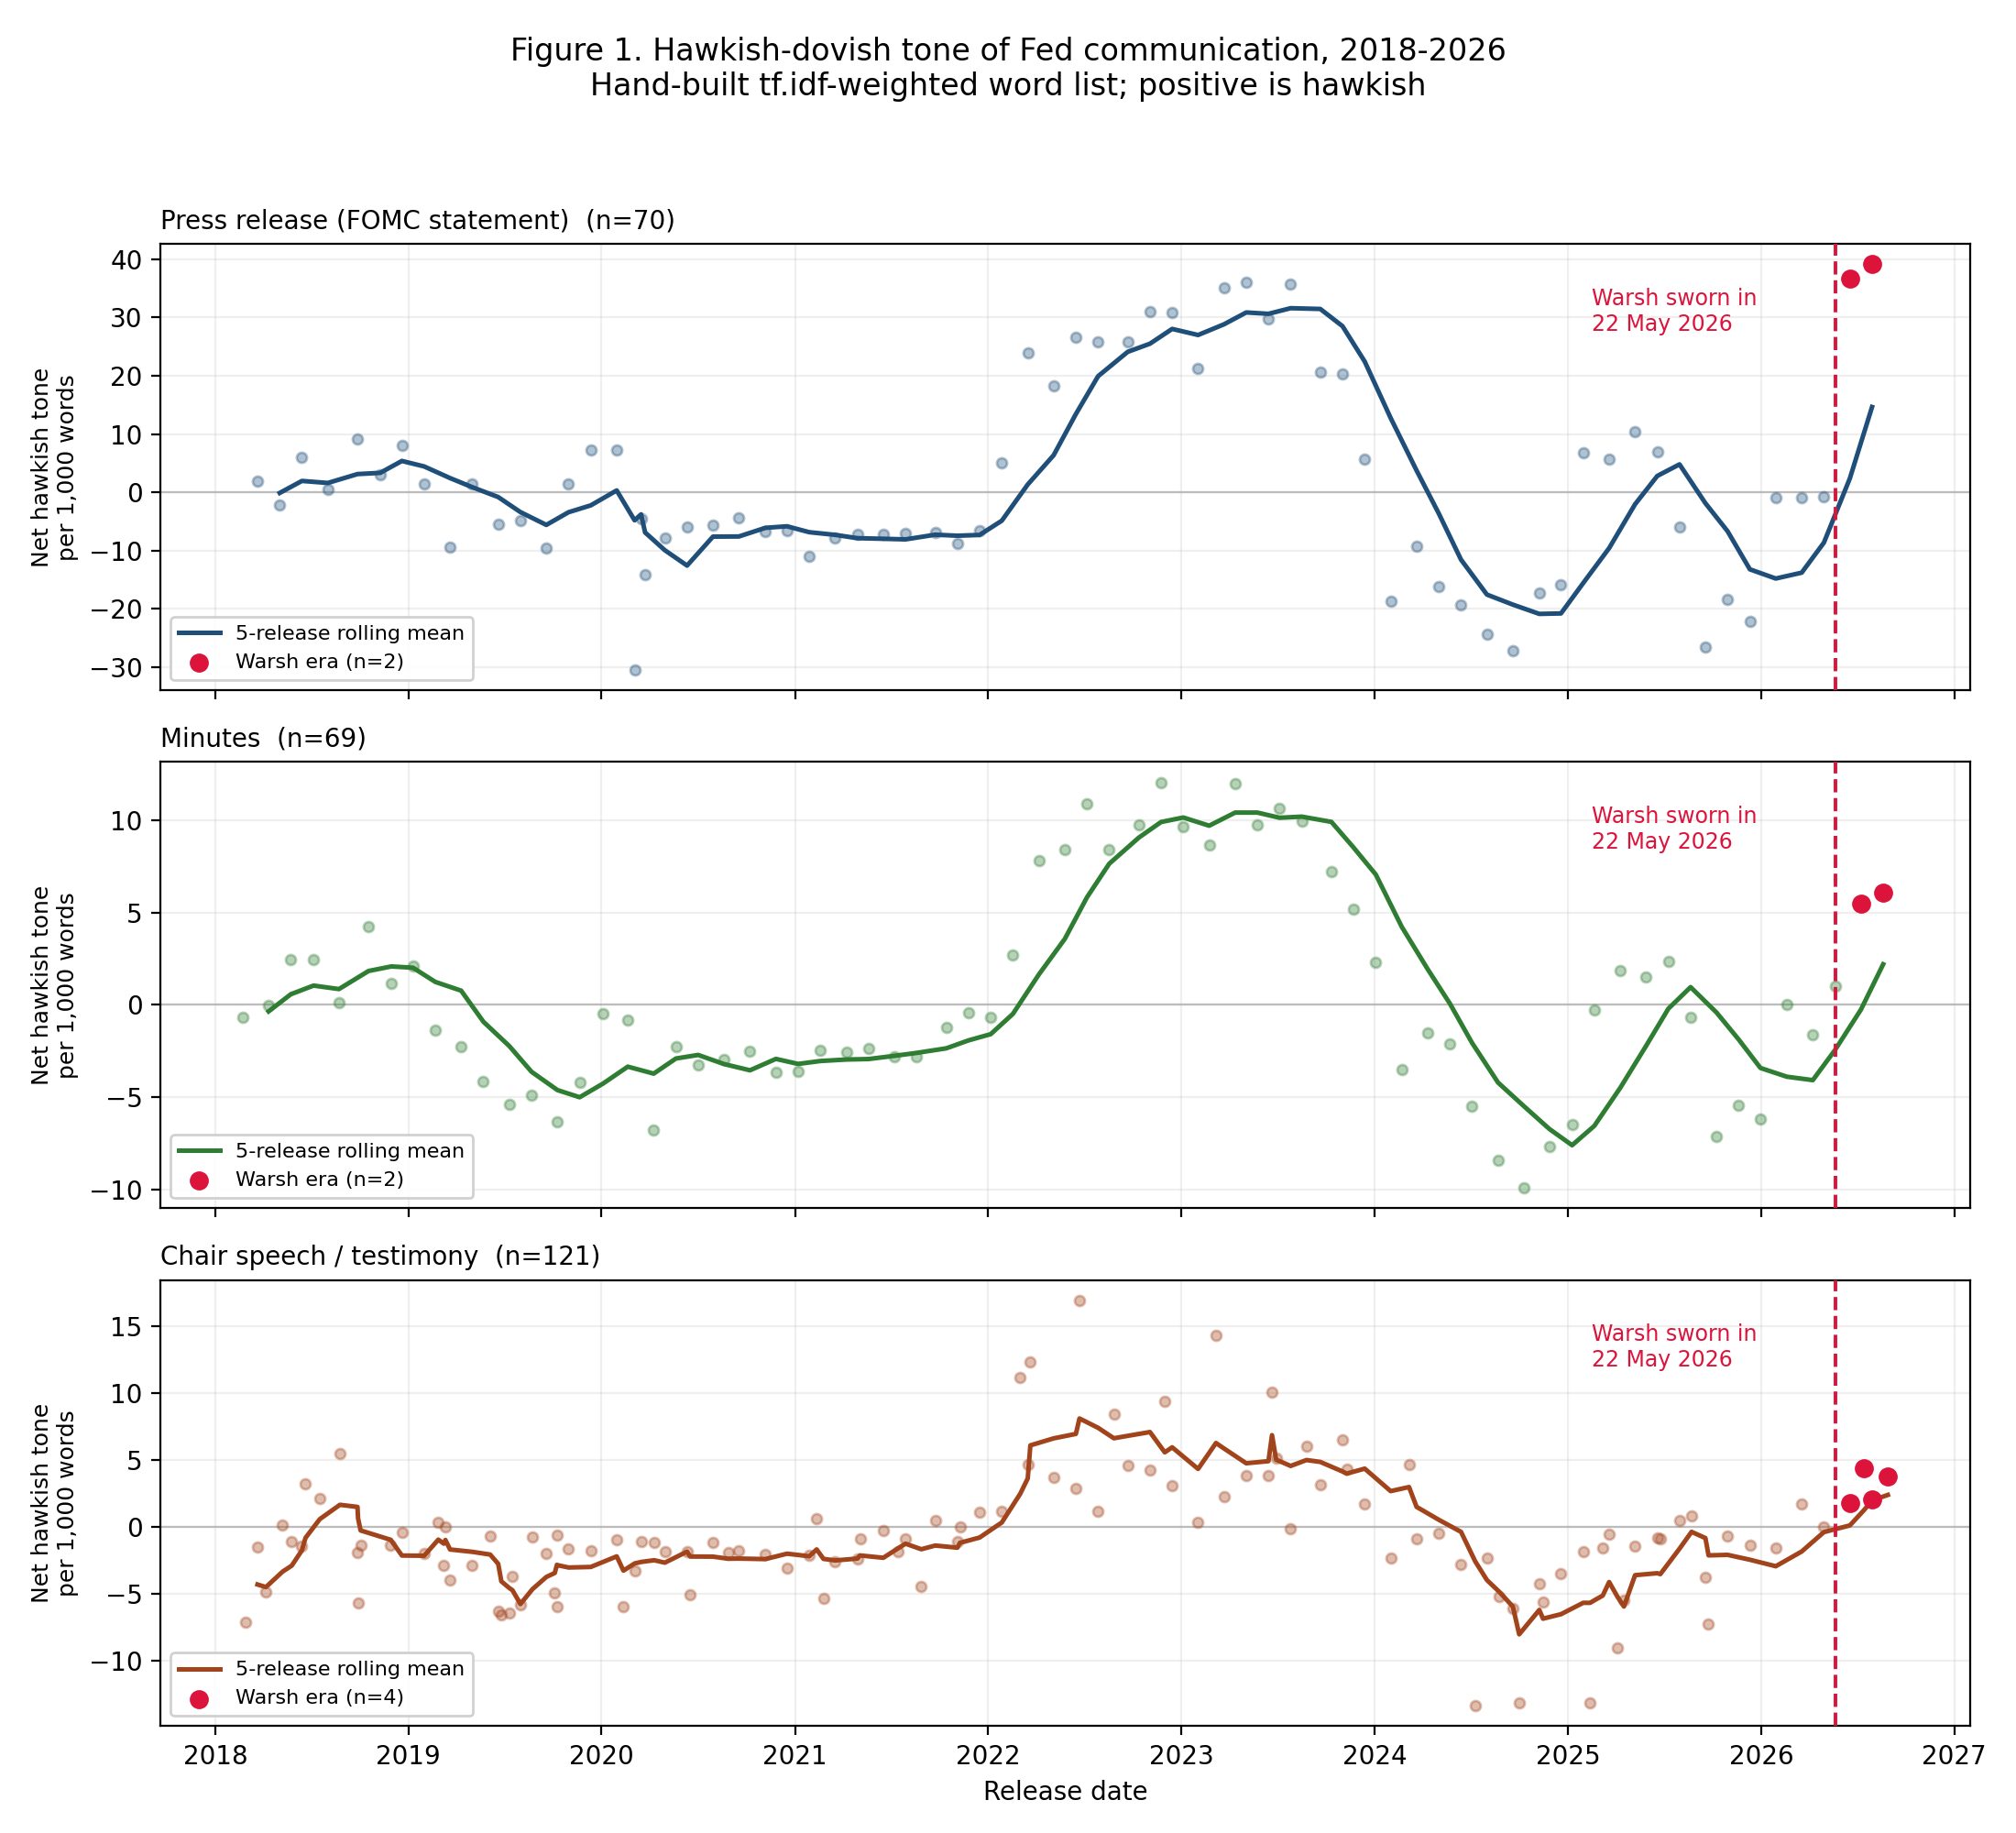

In [8]:
path = exhibits.figure1(scores)
from IPython.display import Image
Image(str(path))

---
## Method 2 (secondary). FinBERT + numeric rate-direction augmentation

FinBERT classifies *financial news sentiment*, which is not the hawk–dove axis. The
augmentation layer reads rate-direction language — raise/lower, magnitude in basis points,
negation for holds — and replaces the sentiment contribution of those sentences.

This is a **rule-based approximation** of the numeric-property fine-tuning in Doh, Song &
Yang (2023), not a reproduction: they put magnitude and direction inside the embeddings by
fine-tuning on synthetic numeric data. See `AI_USE.md`.

In [9]:
from src.score_finbert import direction_signal, ORIENTATION
tests = [
    "The Committee decided to raise the target range for the federal funds rate by 25 basis points.",
    "The Committee decided to raise the target range for the federal funds rate by 50 basis points.",
    "Participants preferred to lower the target range by 1/2 percentage point.",
    "The Committee decided to maintain the target range at 3-1/2 to 3-3/4 percent.",
    "Inflation remains elevated relative to the Committee's 2 percent goal.",
]
for s in tests:
    score, bps = direction_signal(s)
    print(f"  dir={score:+.2f}  bps={bps}   {s[:78]}")

  dir=+0.75  bps=25   The Committee decided to raise the target range for the federal funds rate by 
  dir=+1.00  bps=50   The Committee decided to raise the target range for the federal funds rate by 
  dir=-1.00  bps=50   Participants preferred to lower the target range by 1/2 percentage point.
  dir=+0.00  bps=None   The Committee decided to maintain the target range at 3-1/2 to 3-3/4 percent.
  dir=+0.00  bps=None   Inflation remains elevated relative to the Committee's 2 percent goal.


50bp ranks above 25bp, direction is signed correctly, and a hold returns no signal —
the magnitude ordering Doh, Song & Yang fine-tune their encoder to recognise.

### The orientation convention, stated as a hypothesis and tested

Hawkish FOMC text describes *problems* (inflation elevated, price pressures), which FinBERT
reads as negative; dovish text describes *improvement*, which it reads as positive. So
hawkishness should map to negative FinBERT sentiment. That is a claim about the data, so it
is tested on the 252 Powell-era documents rather than assumed.

In [10]:
powell = scores[scores.chair == "Powell"]
print(f"ORIENTATION constant = {ORIENTATION}")
print(f"corr(raw FinBERT sentiment, word list), Powell era N={len(powell)}: "
      f"{powell.tone_finbert.corr(powell.tone_wordlist) * ORIENTATION:+.3f}")
for col in ["tone_finbert", "tone_finbert_aug"]:
    print(f"corr({col:<17}, word list) = {powell[col].corr(powell.tone_wordlist):+.3f}")

ORIENTATION constant = -1.0
corr(raw FinBERT sentiment, word list), Powell era N=252: -0.177
corr(tone_finbert     , word list) = +0.177
corr(tone_finbert_aug , word list) = +0.461


The sign is as hypothesised, so the convention stands — but the correlation is weak
(−0.18), and the augmentation lifts agreement with the word list to only +0.46.

### Where the two layers disagree

In [11]:
layers = scores.groupby("chair")[["tone_finbert", "tone_direction",
                                   "tone_finbert_aug"]].mean().round(3)
layers.columns = ["Sentiment layer", "Direction layer", "Blended"]
display(layers)

print("Directional sentences as a share of the corpus: "
      f"{100 * scores.n_directional.sum() / scores.n_sentences.sum():.1f}%")

,Sentiment layer,Direction layer,Blended
chair,,,
Powell,-0.040,0.034,-0.033
Warsh,-0.202,0.464,-0.181


Directional sentences as a share of the corpus: 2.4%


**This is the central result for the comparison section.** The rule layer reads Warsh at
**+0.46** against Powell's **+0.03** — it agrees emphatically with the word list. The frozen
sentiment layer reads him *dovish*, and it dominates the blend, because directional sentences
are only ~2.4% of any document.

Bolting rules onto a frozen model only reaches sentences that happen to state a number. The
June 17 statement contains **zero** rate-direction sentences, so the augmentation cannot touch
it at all. Getting this right requires the numeric property inside the embeddings — which is
precisely what Doh, Song & Yang's fine-tuning does, and precisely what was not feasible here.

In [12]:
from src.score_finbert import split_sentences, _load_model, sentiment_scores
texts = {r.doc_id: open(r.path).read() for r in manifest.itertuples()
         if r.doc_id == "20260617_statement_0"}
bundle = _load_model()
ss = split_sentences(texts["20260617_statement_0"])
for s, v in zip(ss, sentiment_scores(ss, bundle)):
    d, _ = direction_signal(s)
    print(f"  finbert={v:+.2f}  dir={d:+.2f} | {s[:88]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  finbert=+0.04  dir=+0.00 | The Federal Open Market Committee approved the following statement for release by a 12 –
  finbert=+0.11  dir=+0.00 | The Committee decided to maintain the target range for the federal funds rate at 3-1/2 t
  finbert=+0.81  dir=+0.00 | The Committee reaffirmed its policy of maintaining ample reserves in the banking system.
  finbert=+0.94  dir=+0.00 | Economic activity is expanding at a solid pace despite elevated uncertainty that owes, i
  finbert=+0.89  dir=+0.00 | Productivity growth and capital investment are strong.
  finbert=+0.33  dir=+0.00 | Job gains have kept pace with the workforce, and the unemployment rate has changed littl
  finbert=+0.56  dir=+0.00 | Inflation remains elevated relative to the Committee's 2 percent goal, in part reflectin
  finbert=+0.15  dir=+0.00 | The Committee will deliver price stability.


FinBERT scores *"inflation remains elevated relative to the Committee's 2 percent goal"*
as **positive news**, and *"The Committee will deliver price stability"* — the hardest resolve
line in the document — as near-neutral. It is grading the economy, not the policy stance.

---
## Table 2. One-day indicator changes after each Warsh-era release

Release-time rule: a release well before the 16:00 ET close is measured close-to-close over
the release day; one at or after the cut-off is measured over the following session. All
eight Warsh-era releases land before the cut-off, so all are same-day windows.

In [13]:
market = pd.read_csv("data/market/market.csv", index_col=0, parse_dates=True)
panel = validate.build_event_panel(scores, market)
t2 = validate.table2(panel)
display(t2)

,Release (ET),Type,Window,Tone: word list,Tone: FinBERT,Tone: FinBERT aug.,DXY (%),10s2s (bp),1Y (bp),Growth-value (pp),3M bill (bp)
0,2026-06-17 14:00,statement,2026-06-16 to 2026-06-17,36.60,-0.479,-0.479,0.553,-9.0,14.0,-0.258,4.0
1,2026-06-17 14:30,speech,2026-06-16 to 2026-06-17,1.81,-0.070,-0.070,0.553,-9.0,14.0,-0.258,4.0
2,2026-07-08 14:00,minutes,2026-07-07 to 2026-07-08,5.49,-0.156,-0.115,-0.089,-1.0,0.0,1.506,1.0
3,2026-07-14 08:30,speech,2026-07-13 to 2026-07-14,4.37,-0.185,-0.185,-0.336,4.0,-10.0,1.431,-5.0
4,2026-07-29 14:00,statement,2026-07-28 to 2026-07-29,39.10,-0.410,-0.323,-0.572,10.0,-5.0,-0.966,-7.0
5,2026-07-29 14:30,speech,2026-07-28 to 2026-07-29,2.06,-0.067,-0.062,-0.572,10.0,-5.0,-0.966,-7.0
6,2026-08-19 14:00,minutes,2026-08-18 to 2026-08-19,6.05,-0.140,-0.107,-0.823,-6.0,1.0,-0.842,0.0
7,2026-08-28 10:00,speech,2026-08-27 to 2026-08-28,3.79,-0.107,-0.107,0.545,-8.0,11.0,-0.208,6.0


Two caveats that shape Table 3:

1. **Eight releases, six market days.** June 17 and July 29 each carry a statement *and* its
   press conference, so those pairs share one market window and the dependent variable
   repeats. Table 3 is therefore run both ways.
2. **Direction of the moves is mixed.** The 1Y rose 14bp on June 17 and fell 5bp on July 29,
   despite both statements scoring near-identically hawkish. With six days, single events
   dominate.

---
## Table 3. Indicator change regressed on tone, controlling for the 3-month bill

The control is the design, not a nuisance. Doh, Kim & Yang (2021) find qualitative tone moves
bond prices about as much as the rate decision itself; holding the 3-month bill fixed absorbs
the decision, so what loads on tone is *how* the Committee said it rather than *what* it did.

`R2 from tone` is the increment over a control-only regression — the full R² is flattered by
the control, which mechanically explains most of the yield indicators.

In [14]:
t3_release = validate.table3(panel, collapse=False)
display(t3_release)

t3_day = validate.table3(panel, collapse=True)
display(t3_day)

,Indicator,Units,Tone measure,N,Beta (tone),Beta (3M bill),R2,R2 (control only),R2 from tone,Expected sign,Sign matches
0,DXY,%,tone_wordlist,8,0.0053,0.0912,0.678,0.657,0.021,+,True
1,DXY,%,tone_finbert,8,-0.5199,0.0903,0.677,0.657,0.020,+,False
2,DXY,%,tone_finbert_aug,8,-0.7316,0.0888,0.693,0.657,0.035,+,False
3,T10Y2Y,bp,tone_wordlist,8,0.0029,-1.5014,0.915,0.915,0.000,-,False
4,T10Y2Y,bp,tone_finbert,8,0.9766,-1.5050,0.915,0.915,0.000,-,False
5,T10Y2Y,bp,tone_finbert_aug,8,1.6630,-1.5021,0.916,0.915,0.001,-,False
6,DGS1,bp,tone_wordlist,8,0.1256,1.6729,0.857,0.813,0.044,+,True
7,DGS1,bp,tone_finbert,8,-8.7149,1.6424,0.834,0.813,0.021,+,False
8,DGS1,bp,tone_finbert_aug,8,-9.8019,1.6181,0.837,0.813,0.024,+,False
9,GROWTH_VALUE,pp,tone_wordlist,8,-0.0189,0.0148,0.100,0.014,0.087,-,True


,Indicator,Units,Tone measure,N,Beta (tone),Beta (3M bill),R2,R2 (control only),R2 from tone,Expected sign,Sign matches
0,DXY,%,tone_wordlist,6,0.0196,0.0942,0.643,0.577,0.066,+,True
1,DXY,%,tone_finbert,6,-3.3454,0.1000,0.697,0.577,0.121,+,False
2,DXY,%,tone_finbert_aug,6,-3.6408,0.0937,0.753,0.577,0.177,+,False
3,T10Y2Y,bp,tone_wordlist,6,0.0230,-1.3837,0.875,0.875,0.001,-,False
4,T10Y2Y,bp,tone_finbert,6,4.6442,-1.4119,0.876,0.875,0.001,-,False
5,T10Y2Y,bp,tone_finbert_aug,6,6.3106,-1.4056,0.878,0.875,0.003,-,False
6,DGS1,bp,tone_wordlist,6,0.5129,1.8525,0.989,0.813,0.176,+,True
7,DGS1,bp,tone_finbert,6,-53.3550,1.8648,0.932,0.813,0.119,+,False
8,DGS1,bp,tone_finbert_aug,6,-42.5521,1.7324,0.907,0.813,0.094,+,False
9,GROWTH_VALUE,pp,tone_wordlist,6,-0.0821,-0.0413,0.319,0.001,0.318,-,True


In [15]:
for label, t3 in [("by release (N=8)", t3_release), ("by market day (N=6)", t3_day)]:
    s = t3.groupby("Tone measure").agg(
        sign_hit_rate=("Sign matches", "mean"),
        mean_R2_from_tone=("R2 from tone", "mean")).round(3)
    print(f"\n{label}")
    print(s.to_string())


by release (N=8)
                  sign_hit_rate  mean_R2_from_tone
Tone measure                                      
tone_finbert               0.00              0.013
tone_finbert_aug           0.00              0.017
tone_wordlist              0.75              0.038

by market day (N=6)
                  sign_hit_rate  mean_R2_from_tone
Tone measure                                      
tone_finbert               0.00              0.071
tone_finbert_aug           0.00              0.072
tone_wordlist              0.75              0.140


### Reading Table 3

**N is 8 releases on 6 market days. No p-values are reported, and none should be.** With
three parameters and six to eight observations, conventional significance tests would imply
far more than the data supports. Table 3 describes the Warsh era; it does not test it.

What survives that caveat:

* **The word list gets 3 of 4 signs right** (dollar up, 1Y up, growth underperforms value on
  hawkish tone); it misses the curve slope. **Both FinBERT variants get 0 of 4** — and that is
  one error, not four, since their sign is inverted on the Warsh era, which flips every
  coefficient at once.
* **The word list's largest incremental R² is on the 1-year Treasury (0.18) and the
  growth–value spread (0.32)** in the collapsed spec. Those are exactly the two indicators
  Parsing the Fed's own appendix found the word list explained best. That is a replication on
  a different sample and a different Chair.
* **Tone adds little on top of the control for the yield curve** (`R2 from tone` ≈ 0.00).
  10s2s is mechanically dominated by the front end, which the 3-month bill already captures.

---
## Comparison to the readings

**Loughran & McDonald (2011).** Their finding — that a domain-specific, tf.idf-weighted list
beats a general dictionary — is why Method 1 is hand-built rather than reused. Their own list
would not work here: its categories are about *negativity*, not policy direction, and the
hawk–dove axis cuts across them. Their acknowledged limitation, that word lists ignore word
order and context, is what the ordered-chain matcher with a gap budget partially addresses.

**Doh, Song & Yang (2020/2023), "Deciphering Federal Reserve Communication".** They fine-tune
a Universal Sentence Encoder on synthetic numeric data so the embeddings recognise magnitude
and direction — that a 0.50% hike is more hawkish than 0.25%. Method 2 approximates this with
regex rules, and the result above shows *why the approximation is not a substitute*: rules
reach only the 2.4% of sentences that state a number, so the frozen sentiment layer still
drives the document score. Their Alt A/B/C/D calibration scale is unavailable to us for a
different reason: Warsh-era alternatives will not be declassified until roughly 2031.

**Doh, Kim & Yang (2021), "How You Say It Matters".** They find qualitative risk-assessment
language moves bond prices about as much as the quantitative decision. That validates the
Table 3 design: controlling for the 3-month bill separates the *how* from the *what*. Our
result is weakly consistent — tone carries incremental explanatory power on the 1Y and the
growth–value spread, but not on the curve slope, and at N=6 we cannot claim more than that.

**Parsing the Fed (presentation).** It ran exactly this three-method comparison and found the
word list outperformed both FinBERT variants on the 1-year Treasury and the growth–value
spread, with fine-tuned FinBERT beating plain FinBERT on most indicators. We reproduce the
first finding cleanly. On the second we can only reproduce the *direction*: the augmented
FinBERT beats plain FinBERT on mean incremental R² (0.072 vs 0.071 collapsed) — a margin far
too small to lean on, and a rule layer is not a fine-tune.

---
## Forecast — September 16, 2026

**Generated by Claude from the tables above and market levels as of 2026-09-11,
then reviewed by the author. Disclosed in full in `AI_USE.md`.** The reasoning and
the full write-up are in section 8 of `report/REPORT.pdf`; this cell records the
inputs and the resulting call so the notebook is self-contained.

### Where the market sits going in

Target range 3-1/2 to 3-3/4 percent (midpoint 3.625%), unchanged at both Warsh-era
meetings. As of the last complete FRED observation:

| | Level | vs. funds midpoint |
|---|---|---|
| 3-month bill | 4.07% | **+45bp** |
| 1-year Treasury | 4.35% | **+72bp** |
| 10s2s | +0.33 | flattened from +0.45 in early August |
| DXY | 99.12 | |

A 3-month bill 45bp rich to the midpoint cannot sit there unless a hike inside
three months is substantially priced.

### The call

| Outcome | Probability |
|---|---|
| **Raise 25bp** | **65%** |
| Hold | 30% |
| Raise 50bp | 3% |
| Cut 25bp | 2% |

P(September statement more hawkish than July's +39.10 on the word list): **60%**.

| Indicator | P(rises) | Expected one-day move |
|---|---|---|
| DXY | 55% | +0.10% |
| 10s2s | 40% | −2bp |
| 1-year Treasury | 55% | +3bp |
| Growth minus value | 40% | −0.35pp |

Expected values are small by design: if the hike is priced, delivering it moves
little while *not* delivering it moves a lot, which compresses the expectation
toward zero and leaves the distribution left-skewed.

**Trade: small short IWF / long IWN, September 16 close to September 17 close.**
Growth-value is where tone carries the most incremental explanatory power (0.32)
and where the 3-month bill control explains least on its own (0.001) — so what is
there is attributable to tone rather than to the rate decision the control absorbs.

**What would prove it wrong:** growth-value rising more than +0.5pp on the day; a
hold with the September statement scoring below +20; or the dollar and the 1-year
moving opposite to each other, which would mean the day is not being driven by the
FOMC at all.